In [1]:
# load in the carmenes data
import glob
from figures import *

data_root = "/datax/scratch/ktp/carmenes-lasers/spectra/extracted/"
dir_list = glob.glob(data_root + "/*")

diridx = 10

sci_list = glob.glob(dir_list[diridx] + "/*sci*.fits")


In [2]:
from load_data import load_star

(spec_arr, 
 cont_arr, 
 sigma_arr, 
 wave_arr, 
 obj, 
 ra, 
 dec, 
 date_arr, 
 exptime_arr, 
 airm_arr) = load_star(dir_list[diridx], print_headers=False, print_flux_headers=False)

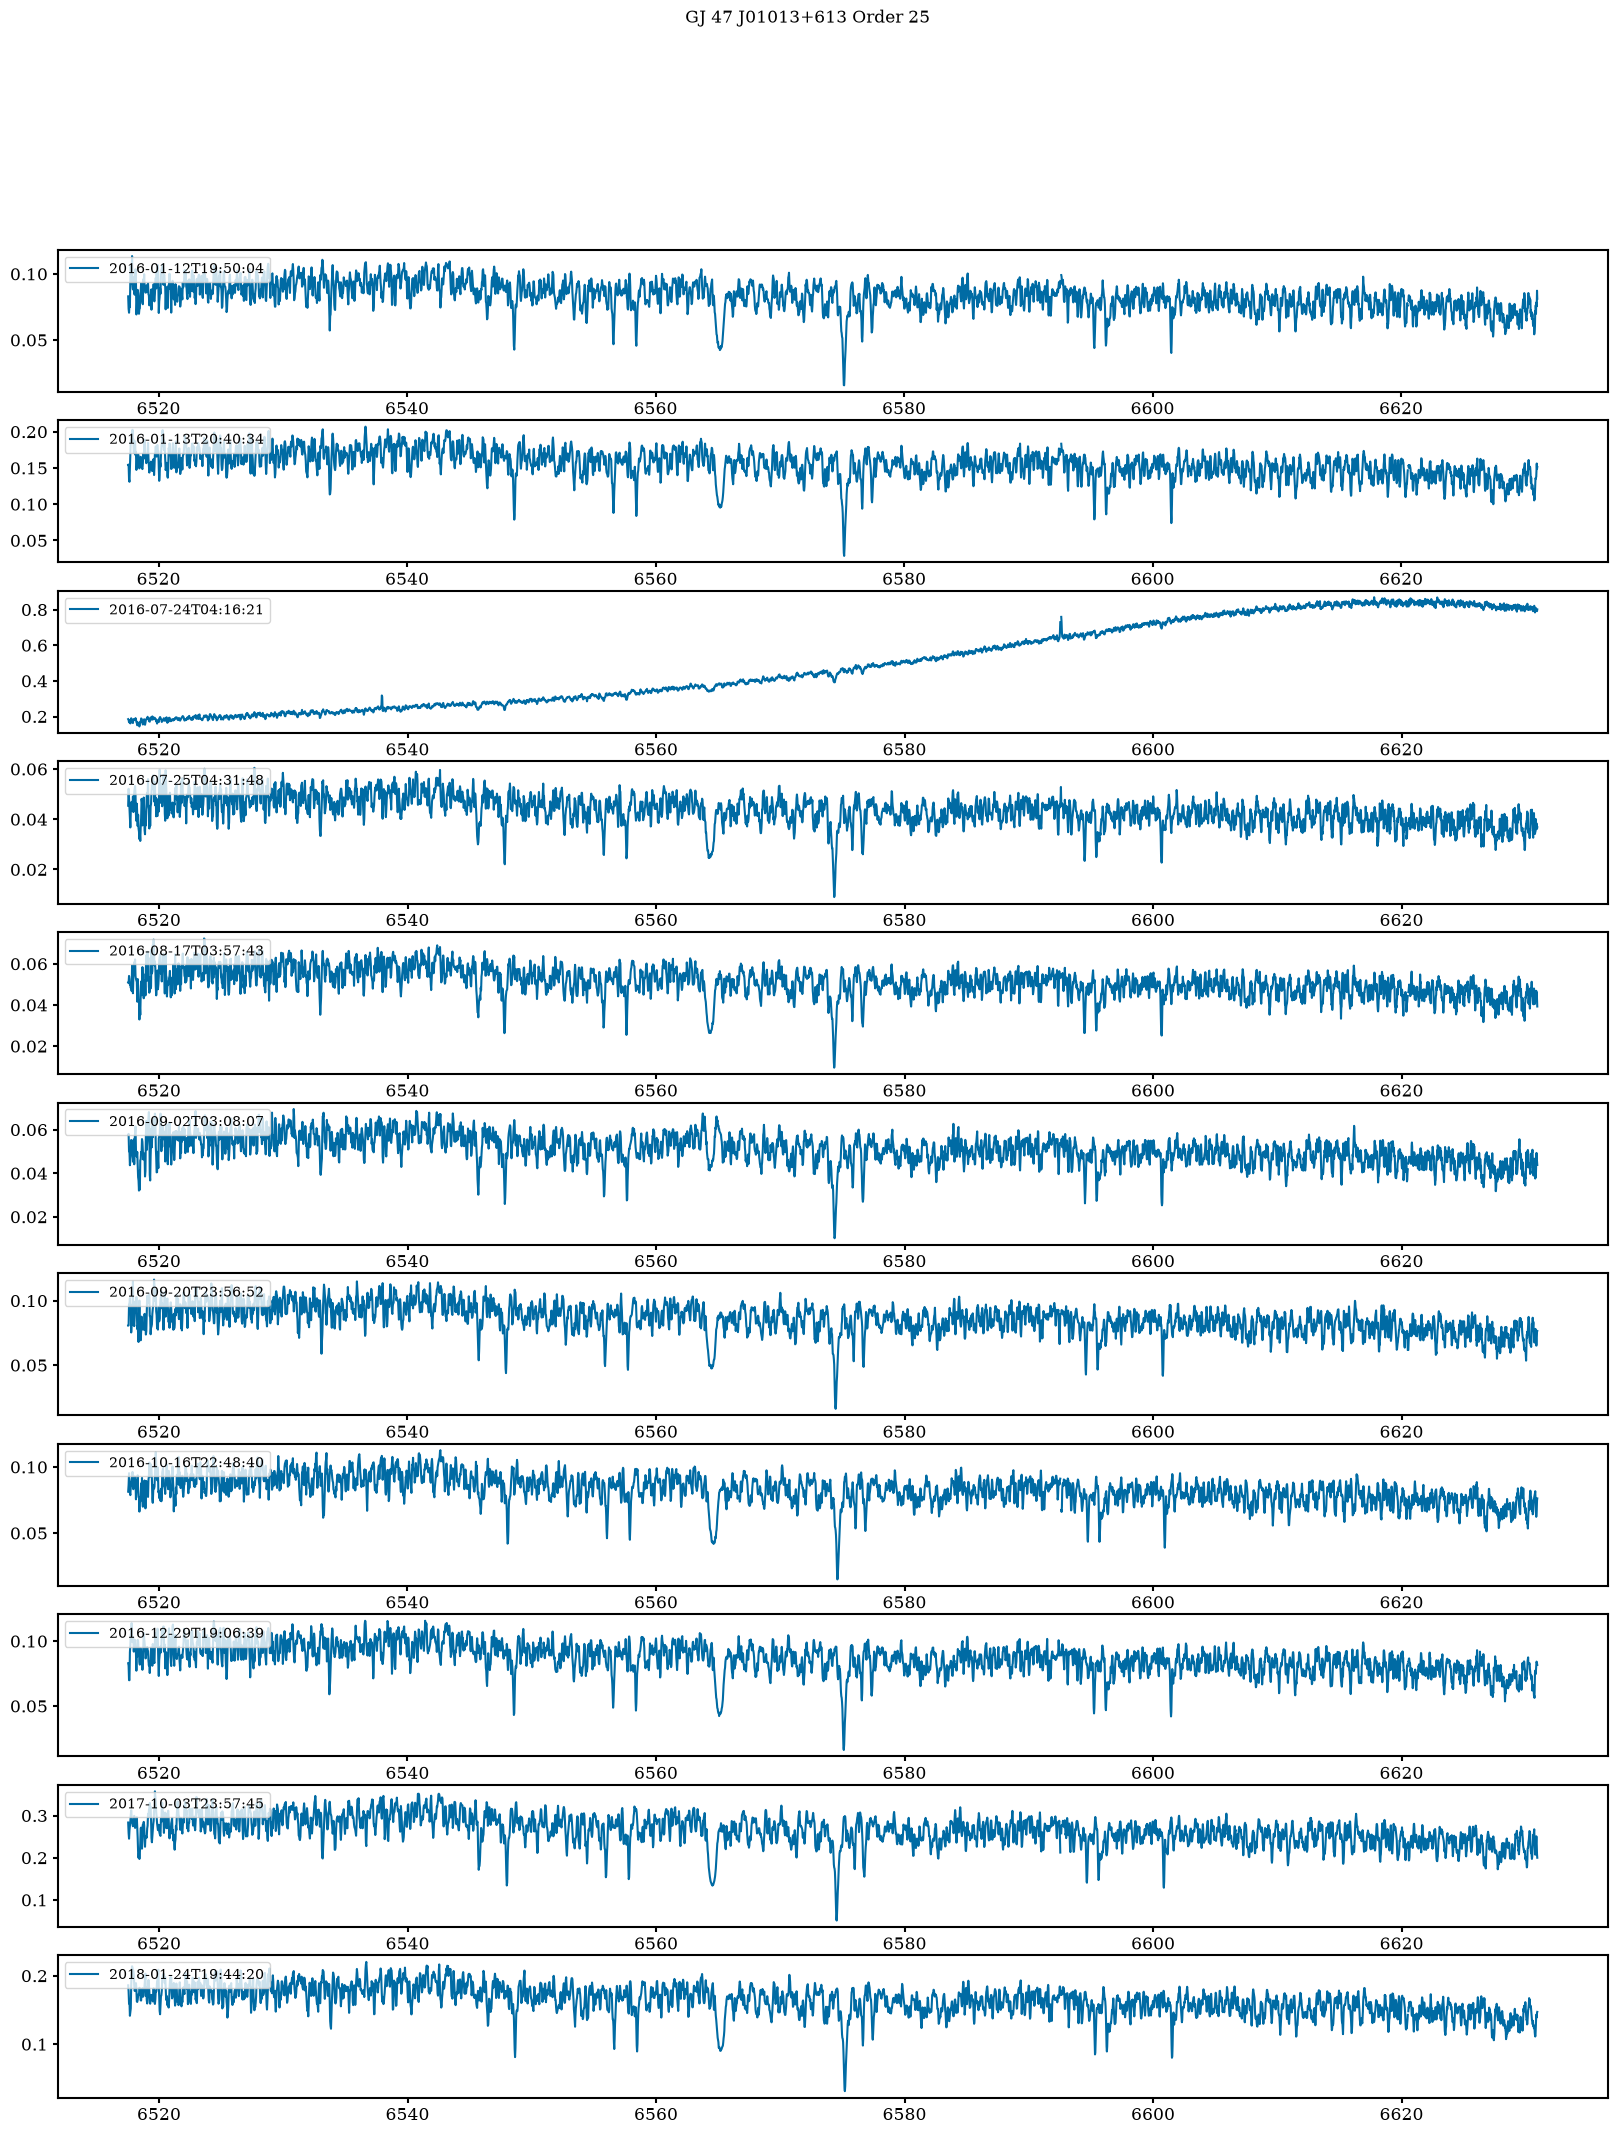

In [48]:
# spec_arr dims are ord, wav, obs
ordidx = 25
n_obs = spec_arr.shape[2]

fig, axs = plt.subplots(n_obs, figsize=(20, 24))
fig.suptitle(f"{obj} Order {ordidx}")
for i in range(n_obs):
    spectra = spec_arr[ordidx, :, i]   # first order, all wavelengths, obs i
    # do something with spectra, e.g.:
    axs[i].plot(wave_arr[ordidx, :, i], spectra, label = f"{date_arr[i]}")
    axs[i].legend(loc="upper left")


In [49]:
for i in range(n_obs):
    spectra = spec_arr[ordidx, :, i]  
    wave = wave_arr[ordidx, :, i]
    print(wave[0], wave[-1])
    

6517.55617238838 6630.957495651431
6517.550571704113 6630.951298937597
6517.520218124022 6630.92002684748
6517.520218124022 6630.92002684748
6517.520300131338 6630.920352225367
6517.5203239895245 6630.920515869476
6517.520685953724 6630.921280885364
6517.521884862649 6630.923016664925
6517.521712698418 6630.924677554348
6517.51122533334 6630.914418841962
6517.516531238575 6630.920079926176


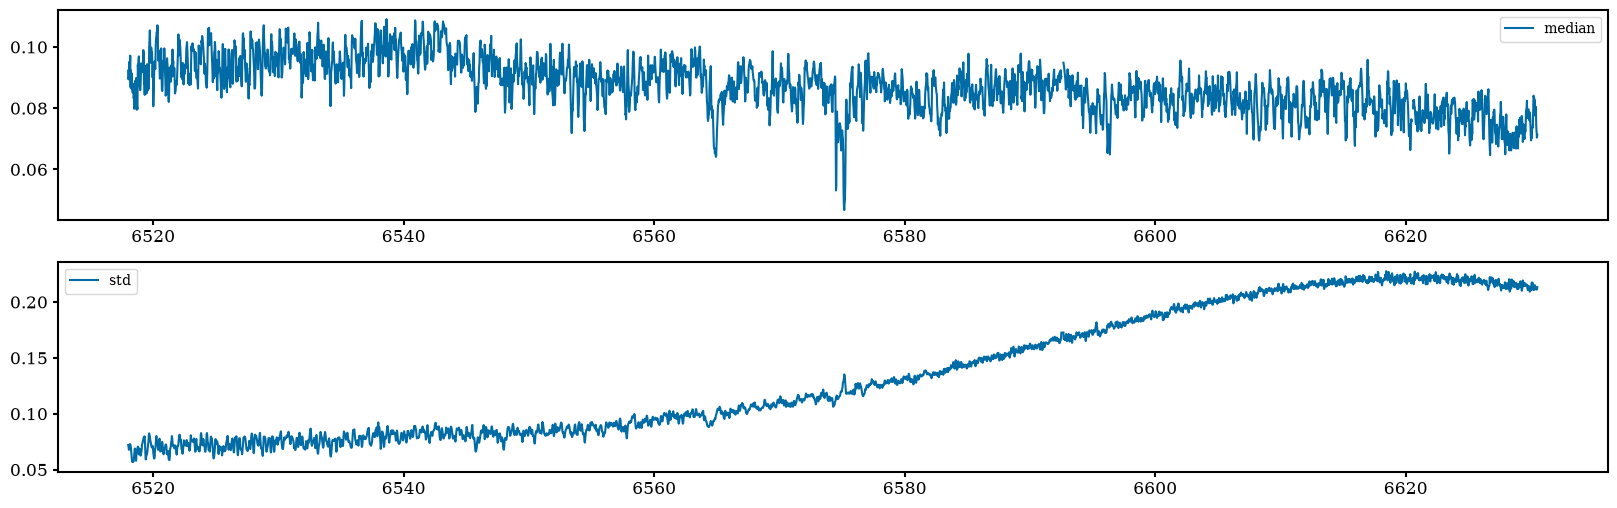

In [50]:
from pipeline import numpy_resample

new_wave, new_spec_arr = numpy_resample(wave_arr, spec_arr, ordidx, step=0.5)
median = np.median(new_spec_arr, axis=1)
std = np.std(new_spec_arr, axis=1)

fig, axs = plt.subplots(2, figsize=(20, 6))
axs[0].plot(new_wave, median, label="median")
axs[1].plot(new_wave, std, label="std")
axs[0].legend()
axs[1].legend()

plt.show()

# fig, axs = plt.subplots(n_obs, figsize=(20, 24))
# fig.suptitle(f"Median-subtracted {obj} Order {ordidx}")
# for i in range(n_obs):
#     spectra = new_spec_arr[:, i] - median  # first order, all wavelengths, obs i
#     # do something with spectra, e.g.:
#     axs[i].plot(new_wave, spectra, label = f"{date_arr[i]}")
#     axs[i].legend(loc="upper left")

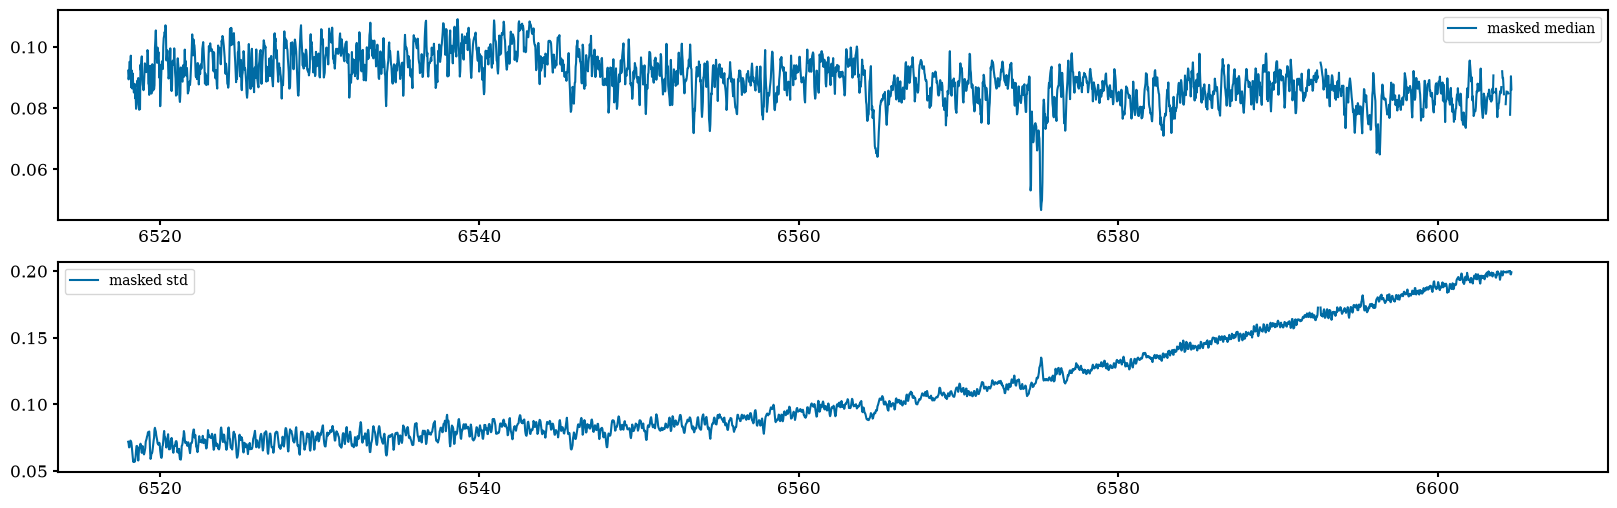

In [51]:
# highlight cols where std > threshold

threshold = 0.2
mask = np.abs(std) > threshold

masked_std = std.copy()
masked_std[mask] = np.nan

masked_median = median.copy()
masked_median[mask] = np.nan
fig, axs = plt.subplots(2, figsize=(20, 6))
axs[0].plot(new_wave, masked_median, label="masked median")
axs[1].plot(new_wave, masked_std, label="masked std")
axs[0].legend()
axs[1].legend()

plt.show()